# Análise Exploratória

-> O objetivo dessa etapa é compreender e analisar a estrutura dos dados, buscamos identificar padrões, relações, outliers, etc.

-> Focaremos a análise no conjunto de dados de treino (`df_treino`)


In [1]:
# Importando bibliotecas dessa análise
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

# Definindo o diretório 
caminho = os.getcwd()

## 1.1 Carregamento e Inspeção Inicial dos Dados

-> Importando os conjuntos de dados de treino e teste e realizar uma rápida inspeção para entender as dimensões dos arquivos e como os dados estão distibuídos com relação a tipos (numéricos,categóricos,etc)

-> `df_treino` na pasta arquivos há um arquivo chamado: data_description, em que você pode verificar, com base no desafio do kagle, as definições de cada coluna.

In [2]:
df_teste = pd.read_csv(os.path.join(caminho, "arquivos", "test.csv"))

df_treino = pd.read_csv(os.path.join(caminho, "arquivos", "train.csv"))


display(df_teste.head())

display(df_teste.info())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

None

In [3]:
# Contagem e separação das variáveis por tipo de dado
colunas_categoricas = df_treino.select_dtypes(include=['object']).columns
colunas_numericas = df_treino.select_dtypes(include=[np.number]).columns

display("=== Resumo dos Tipos de Variáveis ===")
print(f"Total de variáveis: {df_treino.shape[1]}")
print(f"Variáveis Categóricas (object): {len(colunas_categoricas)}")
print(f"Variáveis Numéricas (int/float): {len(colunas_numericas)} \n")

'=== Resumo dos Tipos de Variáveis ==='

Total de variáveis: 81
Variáveis Categóricas (object): 43
Variáveis Numéricas (int/float): 38 



## 1.2 Análise inicial do Dataframe

-> Numa análise inicial Veja que há muitos dados em formato de string. No futuro tratamento desses dados, afinal o dataset possui diversas variáveis categóricas ordinais que podem futuramente sofrer encondings para treinar o modelo.


## 2.1 Estatística Descritiva da Variável Alvo (`SalePrice`)

Realizamos uma análise quantitativa univariada dos preços de venda dos imóveis, calculando medidas de tendência central (Média, Mediana), dispersão (Desvio Padrão, IQR) e Quartis (1º e 3º Quartis).

O objetivo é obter um diagnóstico inicial do comportamento e da distribuição dos dados, fornecendo a base que será  aprofundada nas etapas futuras

In [4]:
# Cálculo das estatísticas descritivas do SalePrice
sale_price = df_treino['SalePrice']

metricas = {
    'Métrica': [
        'Média', 
        'Mediana', 
        'Desvio Padrão', 
        'Mínimo', 
        '1º Quartil (Q1 - 25%)', 
        '3º Quartil (Q3 - 75%)', 
        'Intervalo Interquartil (IQR)', 
        'Máximo',
        'Assimetria (Skewness)', 
        'Curtose (Kurtosis)'
    ],
    'Valor': [
        f"${sale_price.mean():,.2f}",
        f"${sale_price.median():,.2f}",
        f"${sale_price.std():,.2f}",
        f"${sale_price.min():,.2f}",
        f"${sale_price.quantile(0.25):,.2f}",
        f"${sale_price.quantile(0.75):,.2f}",
        f"${(sale_price.quantile(0.75) - sale_price.quantile(0.25)):,.2f}",
        f"${sale_price.max():,.2f}",
        f"{sale_price.skew():.2f}",
        f"{sale_price.kurt():.2f}"
    ]
}

# Apresentação em formato de tabela limpa
df_resumo_estatistico = pd.DataFrame(metricas)
display(df_resumo_estatistico)

,Métrica,Valor
0,Média,"$180,921.20"
1,Mediana,"$163,000.00"
2,Desvio Padrão,"$79,442.50"
3,Mínimo,"$34,900.00"
4,1º Quartil (Q1 - 25%),"$129,975.00"
5,3º Quartil (Q3 - 75%),"$214,000.00"
6,Intervalo Interquartil (IQR),"$84,025.00"
7,Máximo,"$755,000.00"
8,Assimetria (Skewness),1.88
9,Curtose (Kurtosis),6.54


## 2.2 Análise Visual da Distribuição (`SalePrice`) e Teste de Normalidade

Plotamos o histograma dos preços de venda com a curva de densidade real (KDE) sobreposta à curva normal teórica ($\mu$ e $\sigma$ ajustados aos dados). 


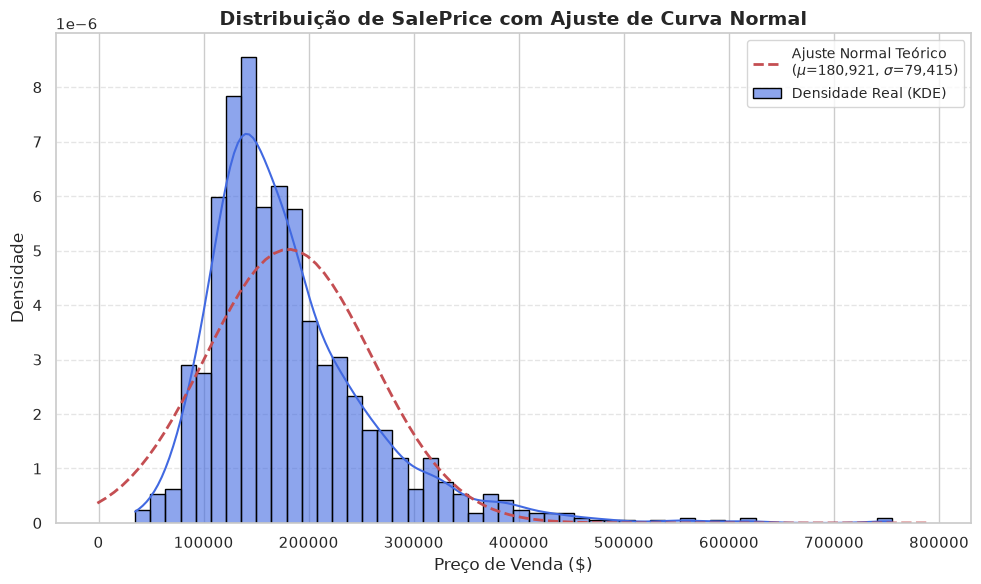

In [5]:
# Configuração da figura
plt.figure(figsize=(10, 6))

# Histograma com estimativa de densidade de Kernel (KDE real)
sns.histplot(
    df_treino['SalePrice'], 
    kde=True, 
    stat="density", 
    color='royalblue', 
    bins=50, 
    edgecolor='black', 
    alpha=0.6, 
    label='Densidade Real (KDE)'
)

#Ajuste e plotagem da Curva Normal Teórica

mu, std = stats.norm.fit(df_treino['SalePrice']) #ajuste normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(
    x, p, 'r--', linewidth=2, 
    label=f'Ajuste Normal Teórico\n($\mu$={mu:,.0f}, $\sigma$={std:,.0f})'
)

# Formatação e Títulos
plt.title('Distribuição de SalePrice com Ajuste de Curva Normal', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda ($)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

> **Análise Visual da Distribuição (2.3):**
>
> * **Concentração de Vendas:** A curva empírica azul (KDE) apresenta um pico mais elevado e deslocado para a esquerda em relação à curva normal teórica (linha tracejada vermelha). 
>
> Isso evidencia que a grande maioria das casas foi comercializada na faixa de **\$130k a \$170k**, valor ligeiramente inferior à média global (\~\$181k).
>
> * **Presença de Imóveis de Alto Padrão:** A extensa cauda à direita revela a existência de um volume reduzido de imóveis com valores muito acima do padrão de mercado, concentrando-se acima de **\$400k**.
>
> * **Conclusão:** Esse comportamento confirma a **assimetria positiva** diagnosticadas nas estatísticas descritivas, indicando que essas poucas vendas atípicas puxam a média geral para cima.


## 2.3 Análise de Outliers com Boxplot

Para complementar a análise de distribuição, utilizamos o diagrama de caixa (*Boxplot*) de modo a poder analisar quartis e outliers.


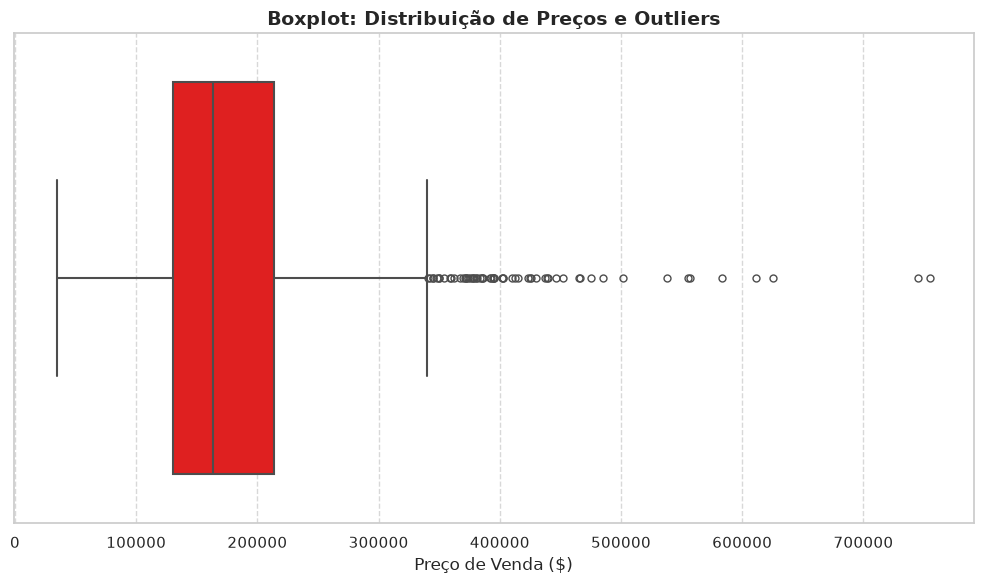

Linha de corte para Outliers Superiores: $340,037.50
Total de imóveis considerados Outliers: 61 casas


In [6]:

plt.figure(figsize=(10,6))
# Geração do Boxplot
sns.boxplot(x=df_treino['SalePrice'], color='red', fliersize=5, linewidth=1.5)

plt.title('Boxplot: Distribuição de Preços e Outliers', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda ($)', fontsize=12)
plt.grid(axis='x', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

# Cálculo extra: Identificando a linha de corte dos outliers superiores
Q1 = df_treino['SalePrice'].quantile(0.25)
Q3 = df_treino['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
qtd_outliers = len(df_treino[df_treino['SalePrice'] > limite_superior])

print(f"Linha de corte para Outliers Superiores: ${limite_superior:,.2f}")
print(f"Total de imóveis considerados Outliers: {qtd_outliers} casas")

> **Diagnóstico Visual**
> * A caixa vermelha concentra 50% dos dados (IQR). A mediana de (\$163.000), que está visivelmente mais próxima do Q1, confirma a assimetria positiva apontada anteriormente.
> * Os pontos (losangos) à direita do limite representam as **61 casas** vendidas por valores superiores a **\$340.037,50**.
> * **Decisão de Modelagem:** A presença forte desses 61 *outliers* indica que, dependendo do modelo escolhido, pode ser necessário aplicar técnicas de regularização ou remoção dos outliers extremos de modo a não distorcer o modelo

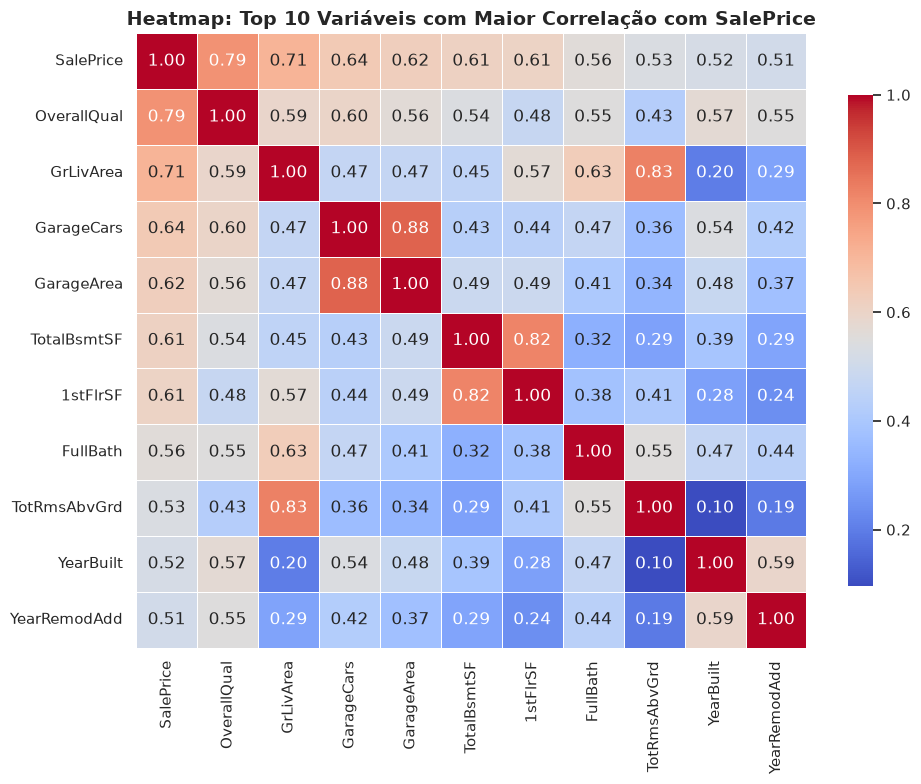

In [7]:
#OBS = Só existem 38 categorias numéricas

# Selecionar apenas as colunas numéricas
colunas_numericas = df_treino.select_dtypes(include=[np.number])

# Calcular a matriz de correlação
matriz_correlacao = colunas_numericas.corr()

# Selecionar as 11 colunas com maior correlação com SalePrice (SalePrice + Top 10)
top_features = matriz_correlacao.nlargest(11, 'SalePrice')['SalePrice'].index

# Filtrar a matriz de correlação apenas com essas colunas
top_corr = df_treino[top_features].corr()

# Plotar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    top_corr, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Esquema de cores (azul para negativo, vermelho para positivo)
    fmt=".2f",           # Formatação para 2 casas decimais
    linewidths=.5,       # Linhas dividindo os quadrados
    cbar_kws={"shrink": .8} # Tamanho da barra de cores lateral
)

plt.title('Heatmap: Top 10 Variáveis com Maior Correlação com SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Principais Insights:**
> 
> 1. **Os Melhores Preditores:** As variáveis `OverallQual` (0.79) e `GrLivArea` (0.71) são as que mais impactam positivamente o `SalePrice`. A qualidade geral e o tamanho da área habitável são, de longe, os fatores mais importantes na precificação.
> 2. **Sinal de Multicolinearidade (Redundância):**
>    * `GarageCars` e `GarageArea` possuem uma correlação altíssima entre si (0.88). É lógico: quanto mais carros cabem, maior a área.  Ou seja, manter os dois é irrelevante
>    * `TotRmsAbvGrd` (Total de Cômodos) e `GrLivArea` (Área Habitável) também estão altamente correlacionadas (0.83).
>    * `1stFlrSF` (Área do 1º andar) e `TotalBsmtSF` (Área do Porão) apresentam forte ligação (0.82).
> 3. **Decisão Prática:** Na etapa de processamento de dados, podemos remover uma variável de cada um desses pares redundantes (por exemplo, remover `GarageArea` e manter apenas `GarageCars`), reduzindo a complexidade do modelo sem perder poder preditivo.

## 2.5  Preditores Principais vs. SalePrice

Após identificar `GrLivArea` (Área Habitável) e `OverallQual` (Qualidade Geral) como os principais impulsionadores do preço de venda, vamos visualizar essas relações diretamente. 

Utilizamos um *Scatter Plot* para a variável contínua (área) a fim de identificar tendências e anomalias lógicas, e um *Boxplot* agrupado para a variável ordinal (qualidade) para verificar a progressão dos preços e a dispersão dentro de cada categoria.

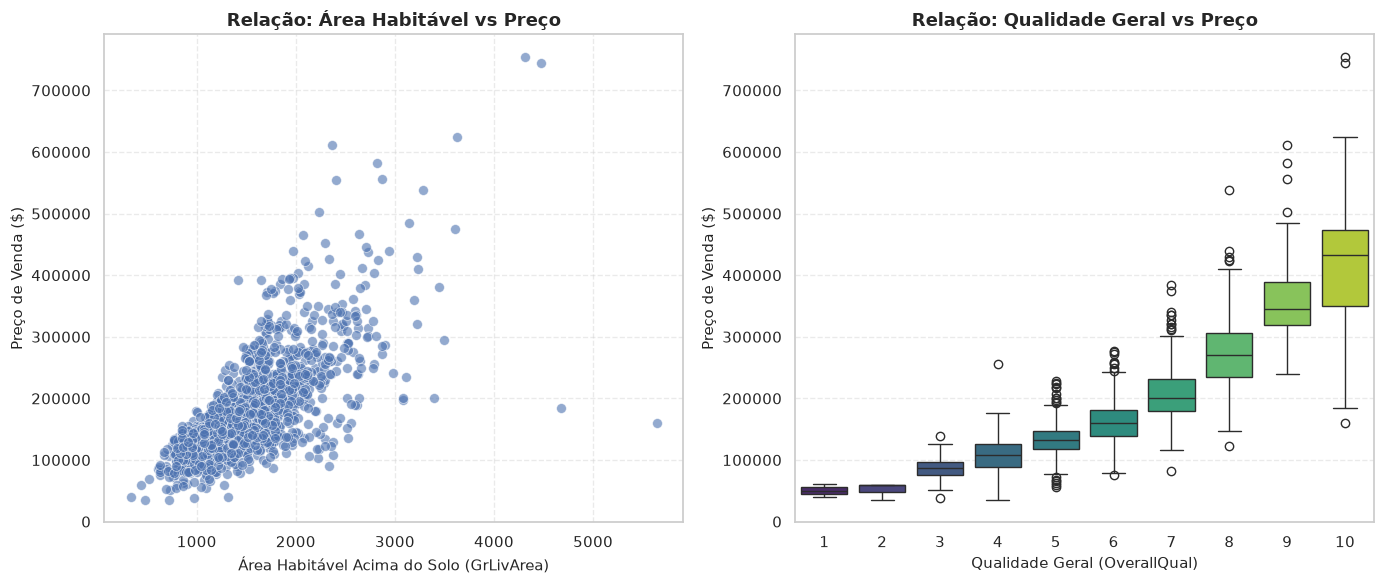

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Gráfico 1: Área Habitável vs Preço (Scatter Plot)
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_treino['GrLivArea'], 
    y=df_treino['SalePrice'], 
    alpha=0.6, 
    color='b', 
    edgecolor='w', 
    s=50
)
plt.title('Relação: Área Habitável vs Preço', fontsize=13, fontweight='bold')
plt.xlabel('Área Habitável Acima do Solo (GrLivArea)', fontsize=11)
plt.ylabel('Preço de Venda ($)', fontsize=11)
plt.grid(alpha=0.4, linestyle='--')

# Gráfico 2: Qualidade Geral vs Preço (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(
    x=df_treino['OverallQual'], 
    y=df_treino['SalePrice'], 
    palette='viridis'
)
plt.title('Relação: Qualidade Geral vs Preço', fontsize=13, fontweight='bold')
plt.xlabel('Qualidade Geral (OverallQual)', fontsize=11)
plt.ylabel('Preço de Venda ($)', fontsize=11)
plt.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

> **Insights**
> 
> 1. **Tendência Clara:** No gráfico da direita, fica evidente que o salto de preço é extremamente relevante conforme a qualidade (notas 8, 9 e 10) aumenta, confirmando sua alta correlação.
> 2. **Identificação de Anomalias (Outliers Lógicos):** No gráfico da esquerda, a relação entre Área e Preço forma um cone ascendente. Contudo, há **dois pontos isolados no canto inferior direito** (casas com mais de 4.000 pés quadrados vendidas por preços irrisórios, abaixo de \$200.000). 
> 3. **Decisão de Modelagem:** Esses dois imóveis gigantes e muito baratos representam ruído extremo (provavelmente vendas agrícolas ou atípicas). 
>
> 4. **Remover apenas essas duas linhas** do dataset de treino é altamente recomendado para proteger qualquer modelo de precificação.